In [ ]:
1+1

2

may 27 validation

step 1

In [ ]:
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"

if services_path not in sys.path: 
    sys.path.append(services_path)

import data_generator
importlib.reload(data_generator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
if not os.path.exists(preset_output_dir): 
    os.makedirs(preset_output_dir)

MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")
def log_universe_generation(params_dict, unique_task_id, preset_name, universe_file):
    """Appends a BRAND NEW row, safely aligning column names."""
    new_row = {
        "Task_ID": unique_task_id,
        "Base_Scenario": preset_name,
        "Timestamp_Step1_Gen": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Universe_Data_File": universe_file,
        "Timestamp_Step2_Calc": "Pending", "n_simulations_used": "Pending", 
        "L1_Scorecard_File": "Pending", "L0_Scorecard_File": "Pending",
        "Timestamp_Step3_Eval": "Pending", "L1_Summary_File": "Pending", "L0_Summary_File": "Pending"
    }
    new_row.update(params_dict) 
    
    df_new = pd.DataFrame([new_row])
    
    # Reverting to your original logic: pd.concat forces Pandas to align columns by name
    if os.path.exists(MASTER_REGISTRY_PATH):
        df_existing = pd.read_csv(MASTER_REGISTRY_PATH)
        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
        df_combined.to_csv(MASTER_REGISTRY_PATH, index=False)
    else:
        df_new.to_csv(MASTER_REGISTRY_PATH, index=False)

        
    # df_new = pd.DataFrame([new_row])
    # if os.path.exists(MASTER_REGISTRY_PATH):
    #     df_existing = pd.read_csv(MASTER_REGISTRY_PATH)
    #     df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    #     df_combined.to_csv(MASTER_REGISTRY_PATH, index=False)
    # else:
    #     df_new.to_csv(MASTER_REGISTRY_PATH, index=False)

# ==============================================================================
# 2. CONFIGURATION ZONE (Easily Editable)
# ==============================================================================
base_params = {
    "n_L1s": 100, 
    "n_L0s_per_L1": 25, 
    "n_children_per_L0": 15,    
    "real_percent_stunting": 35.0, 
    "real_percent_underweight": 33.0, 
    "rho": 0.7,
    "sd_across_units_percent_under_reporting_stunting": 2.0,
    "sd_across_units_percent_under_reporting_underweight": 2.0,
    "sd_within_units_percent_under_reporting_stunting": 1.0,
    "sd_within_units_percent_under_reporting_underweight": 1.0,
    "sd_across_units_bunch_factor_haz": 0.01,
    "sd_across_units_bunch_factor_waz": 0.01,
    "sd_within_units_bunch_factor_haz": 0.01,
    "sd_within_units_bunch_factor_waz": 0.01,
    "sd_percent_copy": 2.0,
    "sd_collusion_index": 0.02,
    "mean_time_lag_L1": 15,
    "mean_time_lag_L2": 30
}

preset_scenarios = {
    "Good_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Good_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_percent_copy": 70.0, 
        "mean_collusion_index": 0.20, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_percent_copy": 20.0, 
        "mean_collusion_index": 0.70, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    }
}

# ==============================================================================
# 3. GENERATION LOOP
# ==============================================================================
print("STEP 1: GENERATING UNIVERSES")
for preset_name, distortion_params in preset_scenarios.items():
    
    current_params = {**base_params, **distortion_params}
    
    run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    unique_task_id = f"{preset_name}_{run_timestamp}"
    
    try:
        child_path, df_pop = data_generator.build_universe(current_params, unique_task_id, preset_output_dir)
        log_universe_generation(current_params, unique_task_id, preset_name, child_path)
        print(f"Generated & Logged: {unique_task_id}")
    except Exception as e:
        print(f"Error on {preset_name}: {e}")

STEP 1: GENERATING UNIVERSES
   -> [Step 1] Building Synthetic Universe for task: Good_L0_Good_L1_20260607_193146
      * Simulating field fraud physics...


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 3527.56it/s]


Generated & Logged: Good_L0_Good_L1_20260607_193146
   -> [Step 1] Building Synthetic Universe for task: Good_L0_Bad_L1_20260607_194520
      * Simulating field fraud physics...


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 869.79it/s]


In [15]:
# step 1 vv small run
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"

if services_path not in sys.path: 
    sys.path.append(services_path)

import data_generator
importlib.reload(data_generator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
if not os.path.exists(preset_output_dir): 
    os.makedirs(preset_output_dir)

MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")
def log_universe_generation(params_dict, unique_task_id, preset_name, universe_file):
    """Appends a BRAND NEW row, safely aligning column names."""
    new_row = {
        "Task_ID": unique_task_id,
        "Base_Scenario": preset_name,
        "Timestamp_Step1_Gen": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Universe_Data_File": universe_file,
        "Timestamp_Step2_Calc": "Pending", "n_simulations_used": "Pending", 
        "L1_Scorecard_File": "Pending", "L0_Scorecard_File": "Pending",
        "Timestamp_Step3_Eval": "Pending", "L1_Summary_File": "Pending", "L0_Summary_File": "Pending"
    }
    new_row.update(params_dict) 
    
    df_new = pd.DataFrame([new_row])
    
    # Reverting to your original logic: pd.concat forces Pandas to align columns by name
    if os.path.exists(MASTER_REGISTRY_PATH):
        df_existing = pd.read_csv(MASTER_REGISTRY_PATH)
        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
        df_combined.to_csv(MASTER_REGISTRY_PATH, index=False)
    else:
        df_new.to_csv(MASTER_REGISTRY_PATH, index=False)

        
    # df_new = pd.DataFrame([new_row])
    # if os.path.exists(MASTER_REGISTRY_PATH):
    #     df_existing = pd.read_csv(MASTER_REGISTRY_PATH)
    #     df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    #     df_combined.to_csv(MASTER_REGISTRY_PATH, index=False)
    # else:
    #     df_new.to_csv(MASTER_REGISTRY_PATH, index=False)

# ==============================================================================
# 2. CONFIGURATION ZONE (Easily Editable)
# ==============================================================================
base_params = {
    "n_L1s": 2, 
    "n_L0s_per_L1": 25, 
    "n_children_per_L0": 15,    
    "real_percent_stunting": 35.0, 
    "real_percent_underweight": 33.0, 
    "rho": 0.7,
    "sd_across_units_percent_under_reporting_stunting": 2.0,
    "sd_across_units_percent_under_reporting_underweight": 2.0,
    "sd_within_units_percent_under_reporting_stunting": 1.0,
    "sd_within_units_percent_under_reporting_underweight": 1.0,
    "sd_across_units_bunch_factor_haz": 0.01,
    "sd_across_units_bunch_factor_waz": 0.01,
    "sd_within_units_bunch_factor_haz": 0.01,
    "sd_within_units_bunch_factor_waz": 0.01,
    "sd_percent_copy": 2.0,
    "sd_collusion_index": 0.02,
    "mean_time_lag_L1": 15,
    "mean_time_lag_L2": 30
}

preset_scenarios = {
    "Good_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Good_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_percent_copy": 70.0, 
        "mean_collusion_index": 0.20, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_percent_copy": 20.0, 
        "mean_collusion_index": 0.70, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    }
}

# ==============================================================================
# 3. GENERATION LOOP
# ==============================================================================
print("STEP 1: GENERATING UNIVERSES")
for preset_name, distortion_params in preset_scenarios.items():
    
    current_params = {**base_params, **distortion_params}
    
    run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    unique_task_id = f"{preset_name}_{run_timestamp}"
    
    try:
        child_path, df_pop = data_generator.build_universe(current_params, unique_task_id, preset_output_dir)
        log_universe_generation(current_params, unique_task_id, preset_name, child_path)
        print(f"Generated & Logged: {unique_task_id}")
    except Exception as e:
        print(f"Error on {preset_name}: {e}")

STEP 1: GENERATING UNIVERSES
   -> [Step 1] Building Synthetic Universe for task: Good_L0_Good_L1_20260607_191935
      * Booting parallel engine using 10 of 20 available CPU cores...
Generated & Logged: Good_L0_Good_L1_20260607_191935
   -> [Step 1] Building Synthetic Universe for task: Good_L0_Bad_L1_20260607_191943
      * Booting parallel engine using 10 of 20 available CPU cores...
Generated & Logged: Good_L0_Bad_L1_20260607_191943
   -> [Step 1] Building Synthetic Universe for task: Bad_L0_Good_L1_20260607_191950
      * Booting parallel engine using 10 of 20 available CPU cores...
Generated & Logged: Bad_L0_Good_L1_20260607_191950
   -> [Step 1] Building Synthetic Universe for task: Bad_L0_Bad_L1_20260607_191958
      * Booting parallel engine using 10 of 20 available CPU cores...
Generated & Logged: Bad_L0_Bad_L1_20260607_191958


step 2

In [31]:
# step 2 v2 
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# CONFIGURATION
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
if services_path not in sys.path: sys.path.append(services_path)

import metrics_calculator
importlib.reload(metrics_calculator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# Identify the parent Universe run you want to use as a baseline
PARENT_UNIVERSE_RUN ="Bad_L0_Bad_L1_20260601_230123"#    "Bad_L0_Bad_L1_20260601_224938"
    # "Good_L0_Good_L1_20260601_205913",
    # "Good_L0_Bad_L1_20260601_210701",
    # "Bad_L0_Good_L1_20260601_212455",
    # "Bad_L0_Bad_L1_20260601_213328"
# ]

# ==============================================================================
# EXECUTION
# ==============================================================================
print("STEP 2: RUNNING NEW OPERATIONAL MATRIX ITERATION")

try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"Registry not found at {MASTER_REGISTRY_PATH}")
    sys.exit()

# Find the parent row to get the population file location
parent_row = registry_df[registry_df['Task_ID'] == PARENT_UNIVERSE_RUN]
if parent_row.empty:
    print(f"Parent Task_ID '{PARENT_UNIVERSE_RUN}' not found in registry.")
    sys.exit()

universe_file_path = parent_row.iloc[0].get('Universe_Population_File')

if not os.path.exists(str(universe_file_path)):
    print(f"Population file does not exist at: {universe_file_path}")
    sys.exit()

# Load the parent universe data
df_universe = pd.read_parquet(str(universe_file_path))

# GENERATE A FRESH TIMESTAMP FOR THE NEW ROW (e.g., Dataset "A2")
current_time = datetime.datetime.now()
timestamp_str = current_time.strftime("%Y%m%d_%H%M%S")
# Keep the base scenario name but assign a unique runtime signature
base_scenario = PARENT_UNIVERSE_RUN.split('_202')[0]
new_task_id = f"{base_scenario}_{timestamp_str}_Step2_Iter"

print(f"\n-> Found parent universe. Spawning new unique run row: {new_task_id}")

try:
    # Run Step 2 using the new task id token (creates uniquely named files)
    l0_matrix_path, l1_matrix_path = metrics_calculator.run_tracer_engine(
        df_pop=df_universe, 
        task_id=new_task_id, 
        output_dir=preset_output_dir,
        n_simulations=1,
        indicators=["Height", "Weight"]
    )
    
    # CONSTRUCT THE NEW REGISTRY ROW
    new_row = {
        'Task_ID': new_task_id,
        'Universe_Population_File': str(universe_file_path),
        'L0_Scorecard_File': str(l0_matrix_path),
        'L1_Scorecard_File': str(l1_matrix_path),
        'L0_Summary_File': 'Pending',
        'L1_Summary_File': 'Pending',
        'Timestamp_Step1_Gen': parent_row.iloc[0].get('Timestamp_Step1_Gen'),
        'Timestamp_Step2_Calc': current_time.strftime("%Y-%m-%d %H:%M:%S"),
        'Timestamp_Step3_Eval': 'Pending'
    }
    
    # Append the row directly to the master registry dataframe
    registry_df = pd.concat([registry_df, pd.DataFrame([new_row])], ignore_index=True)
    registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
    
    print(f"\n✅ SUCCESS! New row added to registry for Task_ID: {new_task_id}")
    
except Exception as e:
    print(f"❌ Error during Step 2 iteration: {e}")

STEP 2: RUNNING NEW OPERATIONAL MATRIX ITERATION
Population file does not exist at: None


SystemExit: 

c:\Users\CEGIS\Documents\GitHub\discsim\venv\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [13]:
# step 2 v3 code
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# CONFIGURATION
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
if services_path not in sys.path: sys.path.append(services_path)

import metrics_calculator
importlib.reload(metrics_calculator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# Identify the parent Universe runs you want to use as baselines
target_tasks = [
    "Bad_L0_Bad_L1_20260604_121926"
    # "Bad_L0_Bad_L1_20260606_134031"
        # "Good_L0_Good_L1_20260601_205913",
        # "Good_L0_Bad_L1_20260601_210701",
        # "Bad_L0_Good_L1_20260601_212455",
        # "Bad_L0_Bad_L1_20260601_213328",
    # "Bad_L0_Bad_L1_20260601_231329"
    # "Good_L0_Good_L1_20260601_205913",
    # "Good_L0_Bad_L1_20260601_210701",
    # "Bad_L0_Good_L1_20260601_212455",
    # "Bad_L0_Bad_L1_20260601_213328"
]

N_SIMULATIONS = 1 # Number of Monte Carlo loops

# ==============================================================================
# EXECUTION
# ==============================================================================
print("STEP 2: RUNNING NEW OPERATIONAL MATRIX ITERATIONS")

try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"Registry not found at {MASTER_REGISTRY_PATH}")
    sys.exit()

# FIX: Loop through each specific task in the list
for PARENT_UNIVERSE_RUN in target_tasks:
    print(f"\n{'-'*60}")
    print(f"Processing Parent Universe: {PARENT_UNIVERSE_RUN}")
    print(f"{'-'*60}")
    
    # Now we compare string to string, which Pandas handles perfectly
    parent_row = registry_df[registry_df['Task_ID'] == PARENT_UNIVERSE_RUN]
    
    if parent_row.empty:
        print(f"❌ Parent Task_ID '{PARENT_UNIVERSE_RUN}' not found in registry. Skipping.")
        continue

    # Get the file path. Note: in your Step 1 log it was called 'Universe_Data_File'
    universe_file_path = parent_row.iloc[0].get('Universe_Data_File')

    if not os.path.exists(str(universe_file_path)):
        print(f"❌ Population file does not exist at: {universe_file_path}. Skipping.")
        continue

    # Load the parent universe data
    print("   * Loading Universe data into memory...")
    df_universe = pd.read_parquet(str(universe_file_path))

    # GENERATE A FRESH TIMESTAMP FOR THE NEW ROW
    current_time = datetime.datetime.now()
    timestamp_str = current_time.strftime("%Y%m%d_%H%M%S")
    
    # Keep the base scenario name but assign a unique runtime signature
    base_scenario = PARENT_UNIVERSE_RUN.split('_202')[0]
    new_task_id = f"{base_scenario}_{timestamp_str}_Step2_Iter"

    print(f"   * Spawning new unique run: {new_task_id}")

    try:
        # Run Step 2 using the new task id token
        l0_matrix_path, l1_matrix_path = metrics_calculator.run_tracer_engine(
            df_pop=df_universe, 
            task_id=new_task_id, 
            output_dir=preset_output_dir,
            n_simulations=N_SIMULATIONS,
            indicators=["Height", "Weight"]
        )
        
        # CONSTRUCT THE NEW REGISTRY ROW
        new_row = {
            'Task_ID': new_task_id,
            'Base_Scenario': base_scenario,
            'Universe_Data_File': str(universe_file_path),
            'L0_Scorecard_File': str(l0_matrix_path),
            'L1_Scorecard_File': str(l1_matrix_path),
            'L0_Summary_File': 'Pending',
            'L1_Summary_File': 'Pending',
            'Timestamp_Step1_Gen': parent_row.iloc[0].get('Timestamp_Step1_Gen'),
            'Timestamp_Step2_Calc': current_time.strftime("%Y-%m-%d %H:%M:%S"),
            'Timestamp_Step3_Eval': 'Pending',
            'n_simulations_used': N_SIMULATIONS
        }
        
        # Pull over any parameters from the parent row so the new row has all the config data
        for col in registry_df.columns:
            if col not in new_row and col in parent_row.columns:
                new_row[col] = parent_row.iloc[0][col]
        
        # Append the row directly to the master registry dataframe
        registry_df = pd.concat([registry_df, pd.DataFrame([new_row])], ignore_index=True)
        registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
        
        print(f"✅ SUCCESS! New row added to registry for Task_ID: {new_task_id}")
        
    except Exception as e:
        print(f"❌ Error during Step 2 iteration for {PARENT_UNIVERSE_RUN}: {e}")

print("\n🎉 ALL STEP 2 TASKS COMPLETE.")

STEP 2: RUNNING NEW OPERATIONAL MATRIX ITERATIONS

------------------------------------------------------------
Processing Parent Universe: Bad_L0_Bad_L1_20260604_121926
------------------------------------------------------------
   * Loading Universe data into memory...
   * Spawning new unique run: Bad_L0_Bad_L1_20260606_225327_Step2_Iter
   -> [Step 2] Executing 3D Tensor Math Engine for Task: Bad_L0_Bad_L1_20260606_225327_Step2_Iter
      * Processing Indicator: Height (Tensor Accelerated)...
      * Processing Indicator: Weight (Tensor Accelerated)...
   -> [Step 2] Complete. Matrix Files Extracted to:
      1. C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\calculated_metrics_L0_Bad_L0_Bad_L1_20260606_225327_Step2_Iter.parquet
      2. C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\calculated_metrics_L1_Bad_L0_Bad_L1_20260606_225327_Step2_Iter.parquet
✅ SUCCESS! New row added to 

In [11]:
import pandas as pd
import os

# ==============================================================================
# 1. DEFINE FILE PATHS
# ==============================================================================
preset_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets"

# L0 Files
l0_2sims_path = os.path.join(preset_dir, "calculated_metrics_L0_Good_L0_Good_L1_20260528_125658_Calc_2sims.parquet")
l0_3sims_path = os.path.join(preset_dir, "calculated_metrics_L0_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet")

# L1 Files
l1_2sims_path = os.path.join(preset_dir, "calculated_metrics_L1_Good_L0_Good_L1_20260528_125658_Calc_2sims.parquet")
l1_3sims_path = os.path.join(preset_dir, "calculated_metrics_L1_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet")

# ==============================================================================
# 2. COMPARISON FUNCTION
# ==============================================================================
def compare_parquets(file1, file2, label):
    print(f"\n{'='*60}")
    print(f" COMPARING {label.upper()} SCORECARDS")
    print(f"{'='*60}")
    
    if not os.path.exists(file1) or not os.path.exists(file2):
        print("ERROR: One or both files do not exist. Check paths.")
        return

    df1 = pd.read_parquet(file1)
    df2 = pd.read_parquet(file2)
    
    cols1 = set(df1.columns)
    cols2 = set(df2.columns)
    
    print(f"Row Count [2-Sims]: {len(df1):,}")
    print(f"Row Count [3-Sims]: {len(df2):,}")
    print("-" * 60)
    
    missing_in_3sims = cols1 - cols2
    new_in_3sims = cols2 - cols1
    
    if not missing_in_3sims and not new_in_3sims:
        print("✅ Columns are an EXACT MATCH.")
    else:
        if missing_in_3sims:
            print(f"❌ Columns REMOVED in 3-Sims ({len(missing_in_3sims)}):")
            for c in sorted(missing_in_3sims): print(f"   - {c}")
            
        if new_in_3sims:
            print(f"\n⚠️ Columns ADDED in 3-Sims ({len(new_in_3sims)}):")
            for c in sorted(new_in_3sims): print(f"   + {c}")

# ==============================================================================
# 3. RUN DIAGNOSTICS
# ==============================================================================
compare_parquets(l0_2sims_path, l0_3sims_path, "L0 Clinic")
compare_parquets(l1_2sims_path, l1_3sims_path, "L1 Supervisor")


 COMPARING L0 CLINIC SCORECARDS
Row Count [2-Sims]: 278,400
Row Count [3-Sims]: 417,600
------------------------------------------------------------
✅ Columns are an EXACT MATCH.

 COMPARING L1 SUPERVISOR SCORECARDS
Row Count [2-Sims]: 16,000
Row Count [3-Sims]: 24,000
------------------------------------------------------------
✅ Columns are an EXACT MATCH.


In [12]:
import pandas as pd

l0_file = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\calculated_metrics_L0_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet"

df = pd.read_parquet(l0_file)
print("=== ACTUAL COLUMNS IN FILE ===")
for col in df.columns:
    print(col)

=== ACTUAL COLUMNS IN FILE ===
L1_id
L0_id
Samp_L0_Real_MAE
Samp_L1_Real_MAE
Samp_L1_L0_MAE
Samp_L2_Real_MAE
Samp_L2_L1_MAE
Samp_L2_L0_MAE
Indicator
Sim_ID
L1_Budget_Pct
L1_Total_Kids_Sampled
L1_Label
L2_Budget_Pct
L2_Total_Kids_Sampled
L2_Label
Pop_L0_Real_MAE
Pop_L1_Real_MAE
Pop_L2_Real_MAE
Pop_L1_L0_MAE
Pop_L2_L1_MAE
Pop_L2_L0_MAE
Gap_Samp_vs_Pop_L0_Real
Gap_Samp_vs_Pop_L1_L0


step 3 

In [14]:
# step 3 v2

import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
if services_path not in sys.path: sys.path.append(services_path)

import analytics_ranker
importlib.reload(analytics_ranker)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# ==============================================================================
# 2. MANUAL TARGETS
# ==============================================================================
# NOTE: Make sure these match the NEW timestamped Task_IDs generated by your Step 2
TARGET_CALCULATED_RUNS = [
    "Bad_L0_Bad_L1_20260606_225327_Step2_Iter",
    # "Bad_L0_Bad_L1_20260606_224555_Step2_Iter",
    # "Bad_L0_Bad_L1_20260606_223622_Step2_Iter"
    # "Bad_L0_Bad_L1_20260606_221222_Step2_Iter"
    # "Bad_L0_Bad_L1_20260606_134118_Step2_Iter"
    # "Good_L0_Bad_L1_20260603_221306_Step2_Iter",
    # "Bad_L0_Good_L1_20260604_001321_Step2_Iter",
    # "Bad_L0_Bad_L1_20260604_021251_Step2_Iter"
# "Good_L0_Good_L1_20260602_003532_Step2_Iter",
# "Good_L0_Bad_L1_20260602_010620_Step2_Iter",
# "Bad_L0_Good_L1_20260602_013747_Step2_Iter",
# "Bad_L0_Bad_L1_20260602_020907_Step2_Iter"
#     "Good_L0_Good_L1_20260601_205913",
# "Good_L0_Bad_L1_20260601_210701",
# "Bad_L0_Good_L1_20260601_212455",
# "Bad_L0_Bad_L1_20260601_213328",

    # "Bad_L0_Bad_L1_20260601_231408_Step2_Iter"
    # # "Good_L0_Good_L1_20260528_145250_Calc_1sims"#,
    #  "Good_L0_Bad_L1_20260528_150009_Calc_1sims",
    #  "Bad_L0_Good_L1_20260528_151136_Calc_1sims",
    #  "Bad_L0_Bad_L1_20260528_152028_Calc_1sims"
]

# ==============================================================================
# 3. EVALUATION ENGINE (APPENDS NEW ROWS)
# ==============================================================================
print("STEP 3: EVALUATING FINAL RESULTS (MANUAL TARGET MODE)")
try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"Cannot find Registry at {MASTER_REGISTRY_PATH}. Run Step 1 first!")
    sys.exit()

target_runs = registry_df[registry_df['Task_ID'].isin(TARGET_CALCULATED_RUNS)]

if target_runs.empty:
    print("No matching Task_IDs found in the registry. Did you copy the names correctly?")
    sys.exit()

for index, row in target_runs.iterrows():
    task_id = row['Task_ID']
    l1_scorecard_path = row.get('L1_Scorecard_File')
    l0_scorecard_path = row.get('L0_Scorecard_File')
    
    if pd.isna(l1_scorecard_path) or str(l1_scorecard_path).strip() == "Pending":
        print(f"Skipping {task_id}: Step 2 (Scorecards) not calculated yet.")
        continue
        
    # FIX 1: THE SKIP CHECK FOR "ALREADY EXISTS" HAS BEEN COMPLETELY REMOVED

    print(f"\n=======================================================")
    print(f"Evaluating Overlap Accuracies for: {task_id}...")
    print(f"=======================================================")
    
    if not os.path.exists(str(l1_scorecard_path)) or not os.path.exists(str(l0_scorecard_path)):
        print(f"Could not find Scorecard matrices for {task_id}. Skipping...")
        continue
        
    try:
        # FIX 2: CREATE A NEW TIMESTAMPED TASK_ID FOR STEP 3
        eval_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        eval_task_id = f"{task_id}_Eval_{eval_timestamp}"
        
        path_l0_summary, path_l1_summary = analytics_ranker.process_ranking_analytics(
            l0_parquet_path=str(l0_scorecard_path), 
            l1_parquet_path=str(l1_scorecard_path), 
            output_dir=preset_output_dir, 
            task_id=eval_task_id, # Pass the NEW timestamped ID to the ranker
            target_percentiles=[0.10, 0.20, 0.30,0.40,0.50,0.60,0.70,0.80,0.90]
        )
        
        # FIX 3: CREATE A NEW ROW AND APPEND IT INSTEAD OF OVERWRITING
        new_row = row.copy()
        new_row['Task_ID'] = eval_task_id
        new_row['L0_Summary_File'] = str(path_l0_summary)
        new_row['L1_Summary_File'] = str(path_l1_summary)
        new_row['Timestamp_Step3_Eval'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        registry_df = pd.concat([registry_df, pd.DataFrame([new_row])], ignore_index=True)
        registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
        print(f"Evaluation Complete & New Row Appended for {eval_task_id}")
        
    except Exception as e:
        print(f"Error evaluating {task_id}: {e}")

print("\nSTEP 3 COMPLETE! The Master Registry has been updated with new rows.")

STEP 3: EVALUATING FINAL RESULTS (MANUAL TARGET MODE)

Evaluating Overlap Accuracies for: Bad_L0_Bad_L1_20260606_225327_Step2_Iter...
   -> [Step 3] Executing Analytics Ranking Engine for Task: Bad_L0_Bad_L1_20260606_225327_Step2_Iter_Eval_20260606_225408
      * Reading precalculated matrices from Step 2...
      * Evaluating Clinic (L0) catching accuracies (V2) [Vectorized]...
      * Evaluating Supervisor (L1) catching accuracies (V1, V3) [Vectorized]...
   -> [Step 3] Complete. Unified Final DB Exported to:
      - C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\Tracer_Master_DB_Bad_L0_Bad_L1_20260606_225327_Step2_Iter_Eval_20260606_225408.parquet
      - C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\Tracer_Master_DB_Bad_L0_Bad_L1_20260606_225327_Step2_Iter_Eval_20260606_225408.csv
Evaluation Complete & New Row Appended for Bad_L0_Bad_L1_20260606_225327_Step2_Iter_Eval_20260606_225

[text](../../outputs/Precalculated_Presets/calculated_metrics_L0_Bad_L0_Bad_L1_20260602_020907_Step2_Iter.parquet) [text](../../outputs/Precalculated_Presets/calculated_metrics_L0_Good_L0_Bad_L1_20260602_000050_Step2_Iter.parquet) [text](../../outputs/Precalculated_Presets/calculated_metrics_L0_Good_L0_Bad_L1_20260602_010620_Step2_Iter.parquet) [text](../../outputs/Precalculated_Presets/calculated_metrics_L0_Bad_L0_Good_L1_20260602_013747_Step2_Iter.parquet) [text](../../outputs/Precalculated_Presets/calculated_metrics_L0_Good_L0_Good_L1_20260601_233409_Step2_Iter.parquet) [text](../../outputs/Precalculated_Presets/calculated_metrics_L0_Good_L0_Good_L1_20260602_003532_Step2_Iter.parquet)

In [15]:
import pandas as pd

# Update this path if your directory structure differs
l0_summary = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet"
l1_summary = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet"

df_l0 = pd.read_parquet(l0_summary)
df_l1 = pd.read_parquet(l1_summary)

print("=== NEW L0 (CLINIC) COLUMNS FOR STREAMLIT ===")
for col in df_l0.columns:
    print(f"- {col}")

print("\n=== NEW L1 (SUPERVISOR) COLUMNS FOR STREAMLIT ===")
for col in df_l1.columns:
    print(f"- {col}")

=== NEW L0 (CLINIC) COLUMNS FOR STREAMLIT ===
- Indicator
- Sim_ID
- L1_Budget_Pct
- L1_Label
- L2_Budget_Pct
- L2_Label
- Target_Percentile
- Clinic_Catch_Rate

=== NEW L1 (SUPERVISOR) COLUMNS FOR STREAMLIT ===
- Indicator
- Sim_ID
- L1_Budget_Pct
- L1_Label
- L2_Budget_Pct
- L2_Label
- Target_Percentile
- Supervisor_Catch_Rate


In [1]:
import pandas as pd

# 1. YOUR EXACT FILE PATHS
old_csv_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\final_evaluation_Bad_L0_Bad_L1_20260526_064358_Calc_1sims.csv"
new_l0_parquet = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"

# 2. LOAD FILES
print("Loading files into memory...")
try:
    df_old = pd.read_csv(old_csv_path)
    df_new_l0 = pd.read_parquet(new_l0_parquet)
except FileNotFoundError as e:
    print(f"\n❌ ERROR: Cannot find a file. Please check this path carefully:\n{e.filename}")
    exit()

# 3. COMPARE RESULTS
df_old_height = df_old[df_old['Indicator'] == 'Height']
df_new_l0_height = df_new_l0[df_new_l0['Indicator'] == 'Height']

print("\n=== COMPARING CLINIC (L0) CATCH RATES ===")
print("OLD CODE (V2_MAE_Acc) vs NEW CODE (Clinic_Catch_Rate)\n")

# Print the first 5 rows side-by-side
for i in range(5):
    old_layout = df_old_height.iloc[i]['L1_Label']
    old_score = df_old_height.iloc[i]['V2_MAE_Acc']
    
    new_layout = df_new_l0_height.iloc[i]['L1_Label']
    new_score = df_new_l0_height.iloc[i]['Clinic_Catch_Rate']
    
    print(f"Layout: {old_layout} | Old Score: {old_score:.2f}% | New Score: {new_score:.2f}%")

Loading files into memory...

=== COMPARING CLINIC (L0) CATCH RATES ===
OLD CODE (V2_MAE_Acc) vs NEW CODE (Clinic_Catch_Rate)

Layout: 2C x 15K | Old Score: 36.67% | New Score: 63.33%
Layout: 2C x 15K | Old Score: 36.67% | New Score: 65.00%
Layout: 2C x 15K | Old Score: 18.33% | New Score: 71.11%
Layout: 2C x 15K | Old Score: 36.67% | New Score: 63.33%
Layout: 2C x 15K | Old Score: 36.67% | New Score: 65.00%


In [4]:
import pandas as pd

# 1. FILE PATHS
files = {
    "OLD_CSV": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\final_evaluation_Bad_L0_Bad_L1_20260526_064358_Calc_1sims.csv",
    "NEW_L0_PARQUET (Clinic Data)": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet",
    "NEW_L1_PARQUET (Supervisor Data)": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"
}

# 2. PROFILING ENGINE
for label, path in files.items():
    print(f"\n{'='*80}")
    print(f" PROFILING: {label}")
    print(f"{'='*80}")
    
    try:
        # Load based on extension
        if path.endswith('.csv'):
            df = pd.read_csv(path)
        else:
            df = pd.read_parquet(path)
            
        print(f"Shape: {df.shape[0]:,} Rows  x  {df.shape[1]} Columns\n")
        
        print("--- COLUMNS & DATA TYPES ---")
        for col in df.columns:
            print(f"  > {col:<25} | Type: {df[col].dtype}")
            
        print("\n--- UNIQUE IDENTIFIER VALUES ---")
        # Only print unique values for columns that have 15 or fewer options to keep it clean
        for col in df.columns:
            n_unique = df[col].nunique(dropna=False)
            if n_unique <= 15:
                unique_vals = df[col].dropna().unique().tolist()
                print(f"  > {col} ({n_unique} unique): {unique_vals}")
                
        print("\n--- FIRST ROW PREVIEW ---")
        print(df.head(1).to_string())
        
    except Exception as e:
        print(f"❌ Failed to load {label}. Error: {e}")


 PROFILING: OLD_CSV
Shape: 714 Rows  x  15 Columns

--- COLUMNS & DATA TYPES ---
  > Indicator                 | Type: str
  > L1_Budget_Pct             | Type: str
  > L1_Label                  | Type: str
  > L2_Budget_Pct             | Type: str
  > L2_Label                  | Type: str
  > V1_MAE_Acc                | Type: float64
  > V1_MAE_Std                | Type: float64
  > V2_MAE_Acc                | Type: float64
  > V2_MAE_Std                | Type: float64
  > V3_MAE_Acc                | Type: float64
  > V3_MAE_Std                | Type: float64
  > L1_C                      | Type: int64
  > L1_K                      | Type: int64
  > L2_C                      | Type: int64
  > L2_K                      | Type: int64

--- UNIQUE IDENTIFIER VALUES ---
  > Indicator (2 unique): ['Height', 'Weight']
  > L1_Budget_Pct (10 unique): ['10%', '100%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%']
  > L2_Budget_Pct (10 unique): ['10%', '100%', '20%', '30%', '40%', '50%

In [5]:
import pandas as pd
import numpy as np

# 1. FILE PATHS
old_csv_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\final_evaluation_Bad_L0_Bad_L1_20260526_064358_Calc_1sims.csv"
new_l0_parquet = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"

# 2. LOAD FILES
df_old = pd.read_csv(old_csv_path)
df_new_l0 = pd.read_parquet(new_l0_parquet)

# 3. FILTER & STANDARDIZE THE NEW DATA
# Filter to only the 30% Target Percentile (to match the old locked code)
df_new_30 = df_new_l0[df_new_l0['Target_Percentile'] == '30%'].copy()

# Replace underscores with spaces to match the old format
df_new_30['L1_Label_Clean'] = df_new_30['L1_Label'].str.replace('_', ' ')
df_new_30['L2_Label_Clean'] = df_new_30['L2_Label'].str.replace('_', ' ')

# 4. PREPARE THE MERGE
# Grab just the columns we need to compare
old_subset = df_old[['Indicator', 'L1_Label', 'L2_Label', 'V2_MAE_Acc']].copy()
new_subset = df_new_30[['Indicator', 'L1_Label_Clean', 'L2_Label_Clean', 'Clinic_Catch_Rate']].copy()

# Rename columns so they snap together perfectly
new_subset = new_subset.rename(columns={
    'L1_Label_Clean': 'L1_Label', 
    'L2_Label_Clean': 'L2_Label'
})

# 5. MERGE THEM SIDE-BY-SIDE
merged = pd.merge(old_subset, new_subset, on=['Indicator', 'L1_Label', 'L2_Label'])

print("\n============================================================")
print(" STRICT COMPARISON: CLINICS (L0) AT 30% TARGET BRACKET")
print("============================================================\n")

# Filter just to 'Height' to keep the printout clean
merged_height = merged[merged['Indicator'] == 'Height'].head(15)

for index, row in merged_height.iterrows():
    layout = f"L1: {row['L1_Label']} | L2: {row['L2_Label']}"
    old_score = row['V2_MAE_Acc']
    new_score = row['Clinic_Catch_Rate']
    
    # Check if the math is identical
    if np.isclose(old_score, new_score, atol=0.1):
        match_status = "✅ MATCH"
    else:
        match_status = "❌ DIFF"
        
    print(f"{layout:<35} | Old: {old_score:>6.2f}% | New: {new_score:>6.2f}% | {match_status}")

# Overall check
total_comparisons = len(merged)
total_matches = sum(np.isclose(merged['V2_MAE_Acc'], merged['Clinic_Catch_Rate'], atol=0.1))

print(f"\n📊 Total Matched Rows: {total_matches} out of {total_comparisons}")
if total_matches == total_comparisons:
    print("🚀 THE MATH IS A 100% PERFECT MATCH!")


 STRICT COMPARISON: CLINICS (L0) AT 30% TARGET BRACKET

L1: 6C x 6K | L2: 6C x 6K           | Old:  25.00% | New:  20.56% | ❌ DIFF
L1: 6C x 6K | L2: 1C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 3K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 5C x 3K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 3C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 6C x 3K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 4C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 4C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 4C x 6K           | Old: 

In [6]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# ==============================================================================
# 1. DEFINE YOUR EXACT 8 PARQUET FILES
# ==============================================================================
file_pairs = [
    {
        "scenario": "Bad_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"
    },
    {
        "scenario": "Bad_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet"
    },
    {
        "scenario": "Good_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet"
    },
    {
        "scenario": "Good_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet"
    }
]

print("Bridging Microservice Parquets back to Monolith CSV...")
master_list = []

# ==============================================================================
# 2. PROCESS AND MERGE ALL SCENARIOS
# ==============================================================================
for pair in file_pairs:
    scenario_name = pair["scenario"]
    
    # Load the split files
    df_l0 = pd.read_parquet(pair["l0"])
    df_l1 = pd.read_parquet(pair["l1"])
    
    # Strictly filter for the 30% Target Percentile
    targets_l0 = pd.to_numeric(df_l0['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l0_30 = df_l0[np.isclose(targets_l0, 0.30) | np.isclose(targets_l0, 30.0)].copy()
    
    targets_l1 = pd.to_numeric(df_l1['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l1_30 = df_l1[np.isclose(targets_l1, 0.30) | np.isclose(targets_l1, 30.0)].copy()
    
    # Merge Clinic and Supervisor accuracy back into a single wide row
    merged = pd.merge(
        df_l0_30, 
        df_l1_30, 
        on=['Indicator', 'Sim_ID', 'L1_Budget_Pct', 'L1_Label', 'L2_Budget_Pct', 'L2_Label', 'Target_Percentile'],
        how='inner'
    )
    
    # Inject the old Scenario and Universe metadata strings Streamlit expects
    merged['Scenario'] = scenario_name
    merged['Rho_Model'] = "0.0"
    merged['Universe'] = f"{scenario_name} (rho=0.0)"
    
    master_list.append(merged)

# Combine all 4 scenarios into one massive dataframe
final_df = pd.concat(master_list, ignore_index=True)

# ==============================================================================
# 3. TRANSLATE TO LEGACY STRUCTURE
# ==============================================================================
# Format Percentages back to strings (0.1 -> "10%")
final_df['L1_Budget_Pct_Str'] = (final_df['L1_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"
final_df['L2_Budget_Pct_Str'] = (final_df['L2_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"

# Format Labels back to spaces ("3C_x_15K" -> "3C x 15K")
final_df['L1_Label_Str'] = final_df['L1_Label'].str.replace('_', ' ')
final_df['L2_Label_Str'] = final_df['L2_Label'].str.replace('_', ' ')

# Extract integer Clinic (C) and Kid (K) counts
final_df['L1_C'] = final_df['L1_Label'].str.split('C').str[0].astype(int)
final_df['L1_K'] = final_df['L1_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)
final_df['L2_C'] = final_df['L2_Label'].str.split('C').str[0].astype(int)
final_df['L2_K'] = final_df['L2_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)

# Map the Catch Rates back to legacy V-names
final_df['V2_MAE_Acc'] = final_df['Clinic_Catch_Rate']
final_df['V1_MAE_Acc'] = final_df['Supervisor_Catch_Rate']
final_df['V3_MAE_Acc'] = final_df['Supervisor_Catch_Rate']  # Legacy Streamlit plots V3

# Fill missing RMSE/P90/Std columns with 0 to prevent Streamlit from crashing
for col in ['V1_MAE_Std', 'V1_RMSE_Acc', 'V1_P90_Acc', 'V2_MAE_Std', 'V2_RMSE_Acc', 'V2_P90_Acc', 'V3_MAE_Std', 'V3_RMSE_Acc', 'V3_P90_Acc']:
    final_df[col] = 0.0

# Define the exact column order your old CSV used
export_cols = [
    'Universe', 'Indicator', 'Sim_ID', 
    'L1_Budget_Pct_Str', 'L1_C', 'L1_K', 'L1_Label_Str', 
    'L2_Budget_Pct_Str', 'L2_C', 'L2_K', 'L2_Label_Str',
    'V1_MAE_Acc', 'V1_MAE_Std', 'V1_RMSE_Acc', 'V1_P90_Acc',
    'V2_MAE_Acc', 'V2_MAE_Std', 'V2_RMSE_Acc', 'V2_P90_Acc',
    'V3_MAE_Acc', 'V3_MAE_Std', 'V3_RMSE_Acc', 'V3_P90_Acc',
    'Scenario', 'Rho_Model'
]

output_df = final_df[export_cols].copy()

# Rename the temporary formatting columns to exactly match the old headers
output_df.rename(columns={
    'L1_Budget_Pct_Str': 'L1_Budget_Pct',
    'L2_Budget_Pct_Str': 'L2_Budget_Pct',
    'L1_Label_Str': 'L1_Label',
    'L2_Label_Str': 'L2_Label'
}, inplace=True)

# ==============================================================================
# 4. EXPORT TO STREAMLIT DIRECTORY WITH DYNAMIC TIMESTAMP
# ==============================================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"Tracer_Master_DB_Height_Weight_{timestamp}.csv"
output_path = rf"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\{output_filename}"

# Ensure directory exists just in case
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_df.to_csv(output_path, index=False)
print("================================================================================")
print(f"✅ SUCCESS! Backward-compatible CSV generated for Streamlit.")
print(f"File Path: {output_path}")
print(f"Total Rows: {len(output_df):,}")
print("================================================================================")

Bridging Microservice Parquets back to Monolith CSV...
✅ SUCCESS! Backward-compatible CSV generated for Streamlit.
File Path: C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\Tracer_Master_DB_Height_Weight_20260528_205504.csv
Total Rows: 2,856


In [7]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# ==============================================================================
# 1. DEFINE YOUR EXACT 4 SCENARIOS & FILE PATHS
# ==============================================================================
# Notice the "scenario" names now perfectly mimic your old '1_Good_L0...' format
file_pairs = [
    {
        "scenario": "4_Bad_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"
    },
    {
        "scenario": "3_Bad_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet"
    },
    {
        "scenario": "2_Good_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet"
    },
    {
        "scenario": "1_Good_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet"
    }
]

print("Bridging Microservice Parquets back to Monolith CSV...")
master_list = []

# ==============================================================================
# 2. PROCESS AND MERGE ALL SCENARIOS
# ==============================================================================
for pair in file_pairs:
    scenario_name = pair["scenario"]
    
    # Load the split files
    df_l0 = pd.read_parquet(pair["l0"])
    df_l1 = pd.read_parquet(pair["l1"])
    
    # Strictly filter for the 30% Target Percentile
    targets_l0 = pd.to_numeric(df_l0['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l0_30 = df_l0[np.isclose(targets_l0, 0.30) | np.isclose(targets_l0, 30.0)].copy()
    
    targets_l1 = pd.to_numeric(df_l1['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l1_30 = df_l1[np.isclose(targets_l1, 0.30) | np.isclose(targets_l1, 30.0)].copy()
    
    # Merge Clinic and Supervisor accuracy back into a single wide row
    merged = pd.merge(
        df_l0_30, 
        df_l1_30, 
        on=['Indicator', 'Sim_ID', 'L1_Budget_Pct', 'L1_Label', 'L2_Budget_Pct', 'L2_Label', 'Target_Percentile'],
        how='inner'
    )
    
    # Inject the old Scenario and Universe metadata strings Streamlit expects
    merged['Scenario'] = scenario_name
    merged['Rho_Model'] = "0.0"
    merged['Universe'] = f"{scenario_name} (rho=0.0)"
    
    master_list.append(merged)

# Combine all 4 scenarios into one massive dataframe
final_df = pd.concat(master_list, ignore_index=True)

# ==============================================================================
# 3. TRANSLATE TO LEGACY STRUCTURE
# ==============================================================================
# Format Percentages back to strings (0.1 -> "10%")
final_df['L1_Budget_Pct_Str'] = (final_df['L1_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"
final_df['L2_Budget_Pct_Str'] = (final_df['L2_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"

# Format Labels back to spaces ("3C_x_15K" -> "3C x 15K")
final_df['L1_Label_Str'] = final_df['L1_Label'].str.replace('_', ' ')
final_df['L2_Label_Str'] = final_df['L2_Label'].str.replace('_', ' ')

# Extract integer Clinic (C) and Kid (K) counts
final_df['L1_C'] = final_df['L1_Label'].str.split('C').str[0].astype(int)
final_df['L1_K'] = final_df['L1_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)
final_df['L2_C'] = final_df['L2_Label'].str.split('C').str[0].astype(int)
final_df['L2_K'] = final_df['L2_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)

# Map the Catch Rates back to legacy V-names
final_df['V2_MAE_Acc'] = final_df['Clinic_Catch_Rate']
final_df['V1_MAE_Acc'] = final_df['Supervisor_Catch_Rate']
final_df['V3_MAE_Acc'] = final_df['Supervisor_Catch_Rate']  # Legacy Streamlit plots V3

# Fill missing RMSE/P90 columns with 0.0 (Removed the _Std columns completely)
for col in ['V1_RMSE_Acc', 'V1_P90_Acc', 'V2_RMSE_Acc', 'V2_P90_Acc', 'V3_RMSE_Acc', 'V3_P90_Acc']:
    final_df[col] = 0.0

# Define the EXACT 22-column order your old CSV used
export_cols = [
    'Universe', 'Indicator', 'Sim_ID', 
    'L1_Budget_Pct_Str', 'L1_C', 'L1_K', 'L1_Label_Str', 
    'L2_Budget_Pct_Str', 'L2_C', 'L2_K', 'L2_Label_Str',
    'V1_MAE_Acc', 'V1_RMSE_Acc', 'V1_P90_Acc',
    'V2_MAE_Acc', 'V2_RMSE_Acc', 'V2_P90_Acc',
    'V3_MAE_Acc', 'V3_RMSE_Acc', 'V3_P90_Acc',
    'Scenario', 'Rho_Model'
]

output_df = final_df[export_cols].copy()

# Rename the temporary formatting columns to exactly match the old headers
output_df.rename(columns={
    'L1_Budget_Pct_Str': 'L1_Budget_Pct',
    'L2_Budget_Pct_Str': 'L2_Budget_Pct',
    'L1_Label_Str': 'L1_Label',
    'L2_Label_Str': 'L2_Label'
}, inplace=True)

# ==============================================================================
# 4. EXPORT TO STREAMLIT DIRECTORY WITH DYNAMIC TIMESTAMP
# ==============================================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"Tracer_Master_DB_Height_Weight_{timestamp}.csv"
output_path = rf"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\{output_filename}"

# Ensure directory exists just in case
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_df.to_csv(output_path, index=False)
print("================================================================================")
print(f"✅ SUCCESS! 100% Perfect Clone CSV generated for Streamlit.")
print(f"File Path: {output_path}")
print(f"Total Rows: {len(output_df):,}")
print("================================================================================")

Bridging Microservice Parquets back to Monolith CSV...
✅ SUCCESS! 100% Perfect Clone CSV generated for Streamlit.
File Path: C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\Tracer_Master_DB_Height_Weight_20260528_210710.csv
Total Rows: 2,856


In [13]:
import pandas as pd
import numpy as np

# Path to the raw Step 1 child data for the Good L0, Good L1 scenario
child_file_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\child_data_Good_L0_Good_L1_20260528_145250.parquet"

try:
    # 1. Load the raw child universe data
    df = pd.read_parquet(child_file_path)

    # 2. Calculate the exact absolute difference between L0 and L1 Z-Scores
    df['HAZ_Diff_L0_L1'] = np.abs(df['L0_haz'] - df['L1_haz'])

    # 3. Print the statistical summary
    print("=== Summary of Absolute HAZ Differences (L0 vs L1) ===")
    print(df['HAZ_Diff_L0_L1'].describe())
    
    # 4. Check if they are ALL exactly zero
    total_zeros = (df['HAZ_Diff_L0_L1'] < 1e-9).sum() # Using 1e-9 to account for tiny floating point rounding
    print(f"\nTotal Records: {len(df)}")
    print(f"Records with exactly 0.0 difference: {total_zeros}")

except Exception as e:
    print(f"Error reading the file: {e}")

=== Summary of Absolute HAZ Differences (L0 vs L1) ===
count    3.750000e+04
mean     1.752121e-03
std      3.792095e-02
min      0.000000e+00
25%      6.661338e-16
50%      1.554312e-15
75%      2.831069e-15
max      2.919806e+00
Name: HAZ_Diff_L0_L1, dtype: float64

Total Records: 37500
Records with exactly 0.0 difference: 37215


=== MAXIMUM ACCURACY POSSIBLE BY SCENARIO (Target: 30%, Height) ===
           Scenario  Max V2 (L1 catches L0)  Max V1 (L2 catches L1)
1. Good L0, Good L1                    51.8                    73.3
 2. Good L0, Bad L1                    36.1                    90.0
 3. Bad L0, Good L1                    98.3                    76.7
  4. Bad L0, Bad L1                    71.1                    86.7


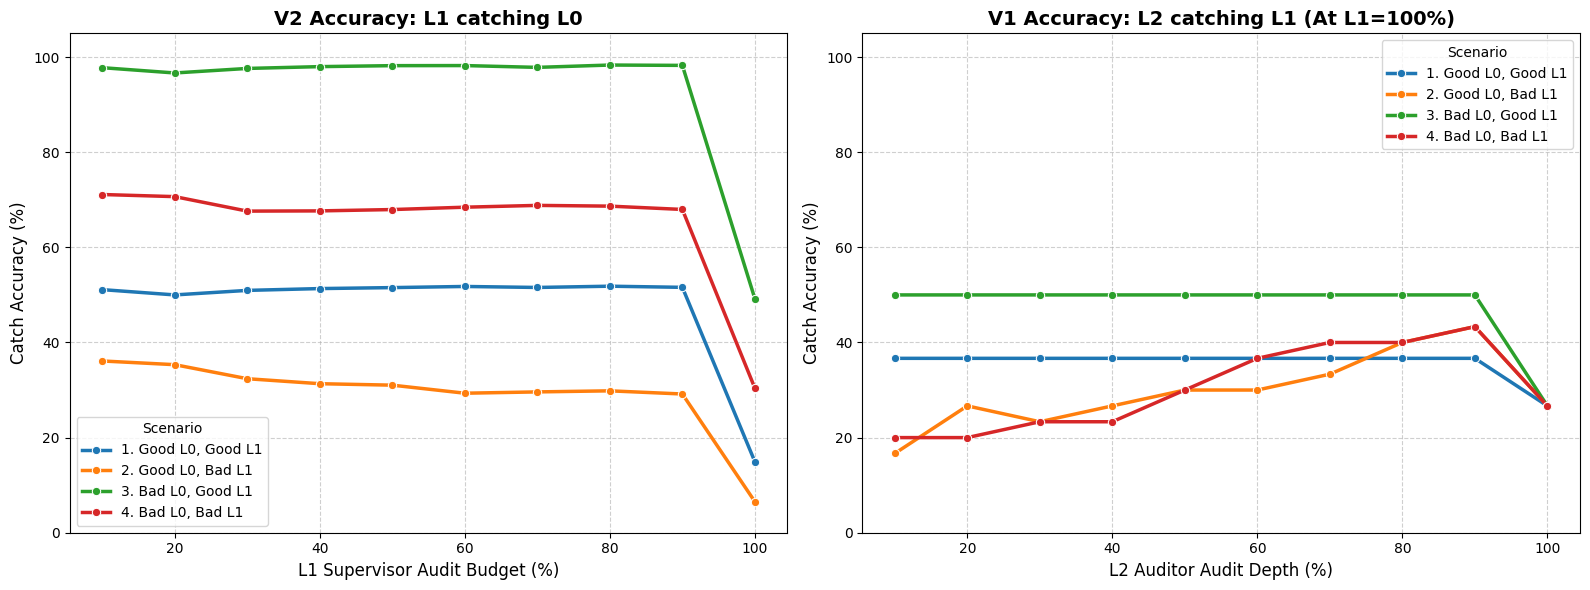

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Point this to your data directory
data_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\may29_ID_validata_bi\data"

# File names
f1 = os.path.join(data_dir, 'Tracer_Master_DB_Good_L0_Good_L1_20260528_145250_Calc_1sims_Eval_20260529_003255.csv')
f2 = os.path.join(data_dir, 'Tracer_Master_DB_Good_L0_Bad_L1_20260528_150009_Calc_1sims_Eval_20260529_014234.csv')
f3 = os.path.join(data_dir, 'Tracer_Master_DB_Bad_L0_Good_L1_20260528_151136_Calc_1sims_Eval_20260529_015516.csv')
f4 = os.path.join(data_dir, 'Tracer_Master_DB_Bad_L0_Bad_L1_20260528_152028_Calc_1sims_Eval_20260529_021745.csv')

# Load and label
df1 = pd.read_csv(f1); df1['Scenario'] = '1. Good L0, Good L1'
df2 = pd.read_csv(f2); df2['Scenario'] = '2. Good L0, Bad L1'
df3 = pd.read_csv(f3); df3['Scenario'] = '3. Bad L0, Good L1'
df4 = pd.read_csv(f4); df4['Scenario'] = '4. Bad L0, Bad L1'

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# 2. FILTER TO 30% TARGET AND HEIGHT
df_30 = df[(df['Target_Percentile'] == '30%') & (df['Indicator'] == 'Height')].copy()

# 3. PRINT THE EXACT ACCURACY TABLES
print("=== MAXIMUM ACCURACY POSSIBLE BY SCENARIO (Target: 30%, Height) ===")
max_acc = df_30.groupby('Scenario')[['V2_MAE_Acc', 'V1_MAE_Acc']].max().reset_index()
max_acc.columns = ['Scenario', 'Max V2 (L1 catches L0)', 'Max V1 (L2 catches L1)']
print(max_acc.round(1).to_string(index=False))

# 4. PLOTTING THE COMPARISON
df_30['L1_Num'] = df_30['L1_Budget_Pct'].str.replace('%', '').astype(int)
df_30['L2_Num'] = df_30['L2_Budget_Pct'].str.replace('%', '').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: How well does L1 catch L0?
v2_data = df_30.groupby(['Scenario', 'L1_Num'])['V2_MAE_Acc'].max().reset_index()
sns.lineplot(data=v2_data, x='L1_Num', y='V2_MAE_Acc', hue='Scenario', ax=axes[0], marker='o', linewidth=2.5)
axes[0].set_title('V2 Accuracy: L1 catching L0', fontsize=14, fontweight='bold')
axes[0].set_xlabel('L1 Supervisor Audit Budget (%)', fontsize=12)
axes[0].set_ylabel('Catch Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 105)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot B: How well does L2 catch L1? (When L1 budget is 100%)
v1_data = df_30[df_30['L1_Budget_Pct'] == '100%'].groupby(['Scenario', 'L2_Num'])['V1_MAE_Acc'].max().reset_index()
sns.lineplot(data=v1_data, x='L2_Num', y='V1_MAE_Acc', hue='Scenario', ax=axes[1], marker='o', linewidth=2.5)
axes[1].set_title('V1 Accuracy: L2 catching L1 (At L1=100%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('L2 Auditor Audit Depth (%)', fontsize=12)
axes[1].set_ylabel('Catch Accuracy (%)', fontsize=12)
axes[1].set_ylim(0, 105)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import os

# 1. Base directory where your Step 1 child data Parquet files are stored
base_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets"

# 2. Map the scenario names to their exact child_data Parquet files
scenarios = {
    "1. Good L0, Good L1": "child_data_Good_L0_Good_L1_20260528_145250.parquet",
    "2. Good L0, Bad L1": "child_data_Good_L0_Bad_L1_20260528_150009.parquet",
    "3. Bad L0, Good L1": "child_data_Bad_L0_Good_L1_20260528_151136.parquet",
    "4. Bad L0, Bad L1": "child_data_Bad_L0_Bad_L1_20260528_152028.parquet"
}

# 3. Loop through each scenario and calculate the differences
for scenario_name, file_name in scenarios.items():
    file_path = os.path.join(base_dir, file_name)
    
    print(f"\n{'='*60}")
    print(f" SCENARIO: {scenario_name}")
    print(f"{'='*60}")
    
    try:
        # Load the raw child universe data
        df = pd.read_parquet(file_path)

        # Calculate the exact absolute difference between L0 and L1 Z-Scores
        df['HAZ_Diff_L0_L1'] = np.abs(df['L0_haz'] - df['L1_haz'])

        # Print the statistical summary
        print("--- Summary of Absolute HAZ Differences (L0 vs L1) ---")
        print(df['HAZ_Diff_L0_L1'].describe().round(4))
        
        # Check if they are ALL exactly zero (using 1e-9 for floating point math)
        total_zeros = (df['HAZ_Diff_L0_L1'] < 1e-9).sum()
        total_records = len(df)
        pct_zero = (total_zeros / total_records) * 100
        
        print(f"\nTotal Records: {total_records:,}")
        print(f"Records with exactly 0.0 difference: {total_zeros:,} ({pct_zero:.2f}%)")

    except FileNotFoundError:
        print(f"Error: Could not find the file {file_name}. Please check the directory.")
    except Exception as e:
        print(f"Error reading the file: {e}")


 SCENARIO: 1. Good L0, Good L1
--- Summary of Absolute HAZ Differences (L0 vs L1) ---
count    37500.0000
mean         0.0018
std          0.0379
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          2.9198
Name: HAZ_Diff_L0_L1, dtype: float64

Total Records: 37,500
Records with exactly 0.0 difference: 37,215 (99.24%)

 SCENARIO: 2. Good L0, Bad L1
--- Summary of Absolute HAZ Differences (L0 vs L1) ---
count    37500.0000
mean         0.1229
std          0.1811
min          0.0000
25%          0.0000
50%          0.0694
75%          0.1429
max          3.6653
Name: HAZ_Diff_L0_L1, dtype: float64

Total Records: 37,500
Records with exactly 0.0 difference: 10,446 (27.86%)

 SCENARIO: 3. Bad L0, Good L1
--- Summary of Absolute HAZ Differences (L0 vs L1) ---
count    37500.0000
mean         0.0943
std          0.3150
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          3.1916
Name: HAZ_Diff_L0_L1, dtype: float6